In [ ]:
#
import os
import re
import numpy as np
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import joblib

Output directory: /content

════════════════════════════════════════════════════════════
  PHISHING SITE DETECTOR — TRAINING PIPELINE
  Dataset : /content/drive/MyDrive/html_content
  Output  : /content
════════════════════════════════════════════════════════════

[1/7] Loading dataset ...
  Loading 1,311 files from 'genuine_site_0' (label=0) ...
  Loading 552 files from 'phishing_site_1' (label=1) ...
  Skipped 4 near-empty/unreadable files.

  Total   : 1,859
  Genuine : 1,310
  Phishing: 549
  Ratio   : 2.39:1 → class_weight='balanced' applied

[2/7] Train/test split (80/20, stratified) ...
  Train: 1,487  |  Test: 372

[3/7] Training 3 models ...

  ▶ Training Logistic Regression ...

  ══════════════════════════════════════════════════
  Logistic Regression
  ══════════════════════════════════════════════════
  Accuracy   : 0.8145  (81.45%)
  Precision  : 0.6496
  Recall     : 0.8091
  F1-Score   : 0.7206

              precision    recall  f1-score   support

     Genuine       0

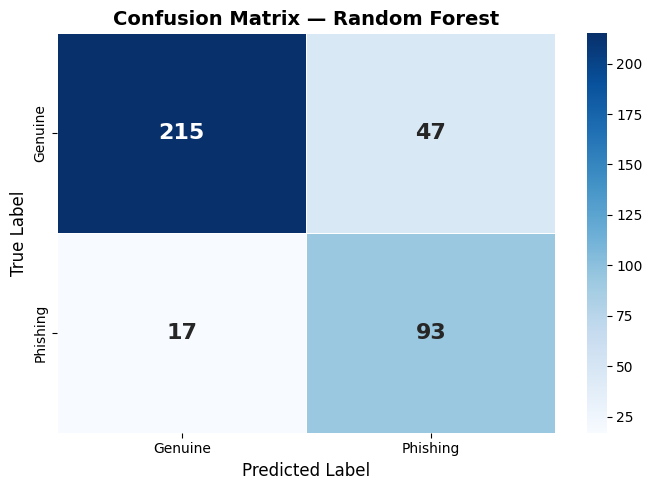


[6/7] Saving model comparison chart ...
  Saved → /content/model_comparison.png


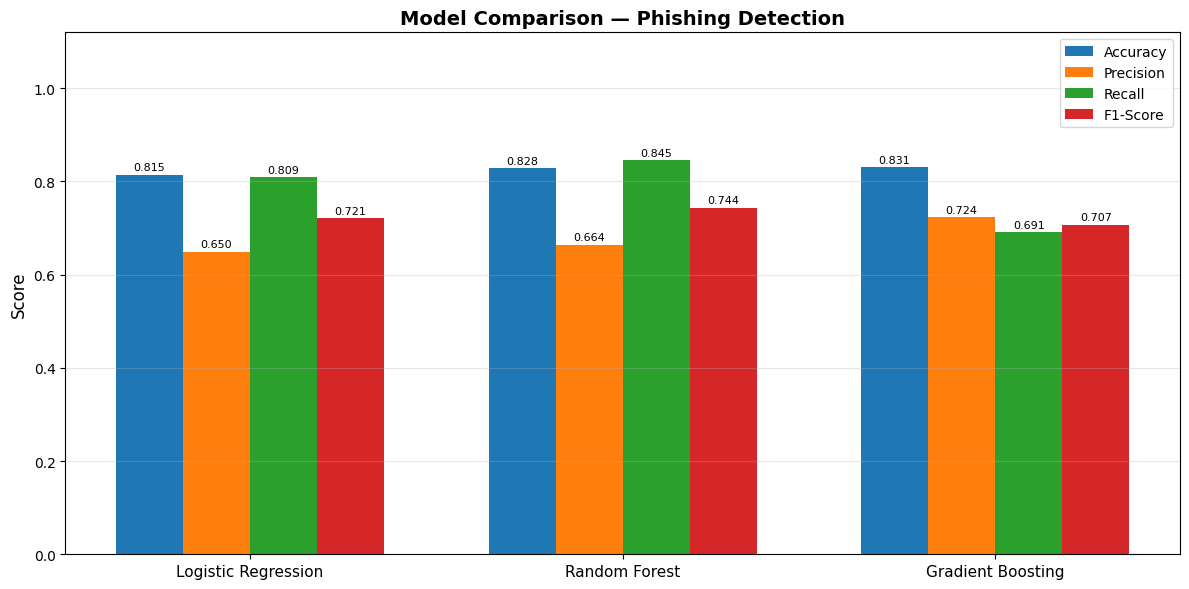


[7/7] Saving model + prediction script ...
  Saved → /content/best_model.pkl
  Saved → /content/predict.py

════════════════════════════════════════════════════════════
  DONE! Files saved to:
  /content/
  ├── best_model.pkl        ← trained model
  ├── predict.py            ← prediction script
  ├── confusion_matrix.png  ← evaluation chart
  └── model_comparison.png  ← all 3 models compared
════════════════════════════════════════════════════════════



In [2]:
"""
Phishing Site Detector - Training Pipeline
==========================================
Configured for Google Colab + Google Drive

Dataset path: /content/drive/MyDrive/html_content/
    genuine_site_0/   --> label 0 (genuine)  [1311 files]
    phishing_site_1/  --> label 1 (phishing) [522 files]

HOW TO USE IN GOOGLE COLAB:
────────────────────────────
Step 1) Mount Drive:
    from google.colab import drive
    drive.mount('/content/drive')

Step 2) Install deps (already available in Colab, but just in case):
    !pip install scikit-learn matplotlib seaborn --quiet

Step 3) Run this script:
    exec(open('train_phishing_detector.py').read())
    OR just paste everything into a Colab cell.
"""

import os
import re
import pickle
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════
DATASET_DIR     = "/content/drive/MyDrive/html_content"
GENUINE_FOLDER  = "genuine_site_0"
PHISHING_FOLDER = "phishing_site_1"
OUTPUT_DIR      = "/content"
TEST_SIZE       = 0.2
RANDOM_SEED     = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ══════════════════════════════════════════════════════════════════
# 1. HTML PREPROCESSING
# ══════════════════════════════════════════════════════════════════
def clean_html(text):
    """
    Extracts meaningful signals from raw HTML for phishing detection.
    Keeps: URL tokens, tag names, script keywords, phishing flag tokens.
    Removes: CSS, base64 blobs, excessive noise.
    """
    # Extract URL values from attributes (key phishing signal)
    urls = re.findall(r'(?:href|src|action)=["\']([^"\']{4,})["\']', text, re.IGNORECASE)
    url_tokens = " ".join(urls)

    # Inject explicit flag tokens for strong phishing indicators
    flags = ""
    if re.search(r'<form',            text, re.IGNORECASE): flags += " HAS_FORM"
    if re.search(r'<iframe',          text, re.IGNORECASE): flags += " HAS_IFRAME"
    if re.search(r'password',         text, re.IGNORECASE): flags += " HAS_PASSWORD"
    if re.search(r'base64,',          text, re.IGNORECASE): flags += " HAS_BASE64"
    if re.search(r'window\.location', text, re.IGNORECASE): flags += " HAS_REDIRECT"
    if re.search(r'document\.cookie', text, re.IGNORECASE): flags += " HAS_COOKIE_ACCESS"
    if re.search(r'eval\s*\(',        text, re.IGNORECASE): flags += " HAS_EVAL"
    if re.search(r'\.exe|\.zip|\.rar',text, re.IGNORECASE): flags += " HAS_DOWNLOAD_LINK"

    # Remove base64 blobs (noise)
    text = re.sub(r'base64,[A-Za-z0-9+/=]{50,}', ' ', text)

    # Remove CSS blocks
    text = re.sub(r'<style[^>]*>.*?</style>', ' ', text, flags=re.DOTALL | re.IGNORECASE)

    # Extract script keywords (cap per block to avoid script-heavy bias)
    script_keywords = []
    for m in re.finditer(r'<script[^>]*>(.*?)</script>', text, re.DOTALL | re.IGNORECASE):
        words = re.findall(r'[a-zA-Z_$][a-zA-Z0-9_$]{3,}', m.group(1))
        script_keywords.extend(words[:60])
    script_text = " ".join(script_keywords)

    # Convert tag names to tokens: <form ...> → TAG_form
    text = re.sub(r'<([a-zA-Z][a-zA-Z0-9]*)[^>]*>', r' TAG_\1 ', text)
    text = re.sub(r'</[^>]+>', ' ', text)

    # Remove HTML entities and symbols
    text = re.sub(r'&[a-zA-Z#0-9]+;', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s._/:-]', ' ', text)

    # Combine all signals
    combined = " ".join([text, url_tokens, script_text, flags])
    combined = re.sub(r'\s+', ' ', combined).strip()

    return combined.lower()


# ══════════════════════════════════════════════════════════════════
# 2. LOAD DATASET
# ══════════════════════════════════════════════════════════════════
def load_dataset():
    texts, labels = [], []
    skipped = 0

    folder_map = {
        GENUINE_FOLDER:  0,
        PHISHING_FOLDER: 1
    }

    for folder_name, label in folder_map.items():
        folder_path = os.path.join(DATASET_DIR, folder_name)

        if not os.path.isdir(folder_path):
            print(f"[ERROR] Folder not found: {folder_path}")
            print(f"        Please check DATASET_DIR in the config section.")
            continue

        files = sorted([
            f for f in os.listdir(folder_path)
            if os.path.isfile(os.path.join(folder_path, f))
        ])
        print(f"  Loading {len(files):,} files from '{folder_name}' (label={label}) ...")

        for fname in files:
            fpath = os.path.join(folder_path, fname)
            try:
                with open(fpath, "r", encoding="utf-8", errors="ignore") as f:
                    raw = f.read()
                cleaned = clean_html(raw)
                if len(cleaned.strip()) < 20:
                    skipped += 1
                    continue
                texts.append(cleaned)
                labels.append(label)
            except Exception:
                skipped += 1

    print(f"  Skipped {skipped} near-empty/unreadable files.")
    return texts, np.array(labels)


# ══════════════════════════════════════════════════════════════════
# 3. MODEL PIPELINES
# ══════════════════════════════════════════════════════════════════
def build_pipelines():
    tfidf_params = dict(
        max_features=60_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.95,
        analyzer="word",
        token_pattern=r"[a-zA-Z0-9_./:_-]{2,}"
    )

    return {
        "Logistic Regression": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_params)),
            ("clf",   LogisticRegression(
                C=5.0, max_iter=1000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=RANDOM_SEED
            ))
        ]),
        "Random Forest": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_params)),
            ("clf",   RandomForestClassifier(
                n_estimators=300, max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced",
                n_jobs=-1,
                random_state=RANDOM_SEED
            ))
        ]),
        "Gradient Boosting": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_params)),
            ("clf",   GradientBoostingClassifier(
                n_estimators=200, learning_rate=0.1,
                max_depth=5, subsample=0.8,
                random_state=RANDOM_SEED
            ))
        ]),
    }


# ══════════════════════════════════════════════════════════════════
# 4. TRAIN + EVALUATE
# ══════════════════════════════════════════════════════════════════
def evaluate_model(name, pipeline, X_train, X_test, y_train, y_test):
    print(f"\n  ▶ Training {name} ...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n  {'═'*50}")
    print(f"  {name}")
    print(f"  {'═'*50}")
    print(f"  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision  : {prec:.4f}")
    print(f"  Recall     : {rec:.4f}")
    print(f"  F1-Score   : {f1:.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Genuine','Phishing'])}")

    return dict(name=name, pipeline=pipeline,
                acc=acc, prec=prec, rec=rec, f1=f1, y_pred=y_pred)


# ══════════════════════════════════════════════════════════════════
# 5. PLOTS
# ══════════════════════════════════════════════════════════════════
def save_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Genuine", "Phishing"],
                yticklabels=["Genuine", "Phishing"],
                linewidths=0.5, ax=ax,
                annot_kws={"size": 16, "weight": "bold"})
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
    plt.savefig(path, dpi=150)
    print(f"  Saved → {path}")
    plt.show()
    plt.close()


def save_comparison_chart(results):
    names   = [r["name"] for r in results]
    metrics = {
        "Accuracy":  [r["acc"]  for r in results],
        "Precision": [r["prec"] for r in results],
        "Recall":    [r["rec"]  for r in results],
        "F1-Score":  [r["f1"]   for r in results],
    }
    x = np.arange(len(names))
    width = 0.18
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (metric, values) in enumerate(metrics.items()):
        bars = ax.bar(x + i * width, values, width, label=metric)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(names, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Model Comparison — Phishing Detection", fontsize=14, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "model_comparison.png")
    plt.savefig(path, dpi=150)
    print(f"  Saved → {path}")
    plt.show()
    plt.close()


# ══════════════════════════════════════════════════════════════════
# 6. SAVE MODEL
# ══════════════════════════════════════════════════════════════════
def save_model(pipeline):
    path = os.path.join(OUTPUT_DIR, "best_model.pkl")
    with open(path, "wb") as f:
        pickle.dump(pipeline, f)
    print(f"  Saved → {path}")


# ══════════════════════════════════════════════════════════════════
# 7. PREDICTION SCRIPT
# ══════════════════════════════════════════════════════════════════
def write_predict_script():
    script = '''"""
Phishing Site Predictor
=======================
Load in Colab:
    from predict import load_model, predict_file
    model = load_model()
    predict_file("/path/to/site.html", model)
"""

import os, re, sys, pickle

MODEL_PATH = "/content/drive/MyDrive/phishing_model/best_model.pkl"

def clean_html(text):
    urls = re.findall(r\'(?:href|src|action)=["\\\\'\\\\']([^"\\\\\'\\\\\']{4,})["\\\\\'\\\\\']\', text, re.IGNORECASE)
    url_tokens = " ".join(urls)
    flags = ""
    checks = [("<form","HAS_FORM"),("<iframe","HAS_IFRAME"),("password","HAS_PASSWORD"),
              ("base64,","HAS_BASE64"),("window.location","HAS_REDIRECT"),
              ("document.cookie","HAS_COOKIE_ACCESS"),("eval(","HAS_EVAL")]
    for pattern, flag in checks:
        if re.search(pattern, text, re.IGNORECASE):
            flags += f" {flag}"
    text = re.sub(r\'base64,[A-Za-z0-9+/=]{50,}\', \' \', text)
    text = re.sub(r\'<style[^>]*>.*?</style>\', \' \', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r\'<script[^>]*>.*?</script>\', \' SCRIPT \', text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r\'<([a-zA-Z][a-zA-Z0-9]*)[^>]*>\', r\' TAG_\\\\1 \', text)
    text = re.sub(r\'</[^>]+>\', \' \', text)
    text = re.sub(r\'&[a-zA-Z#0-9]+;\', \' \', text)
    text = re.sub(r\'[^a-zA-Z0-9\\\\s._/:-]\', \' \', text)
    combined = " ".join([text, url_tokens, flags])
    return re.sub(r\'\\\\s+\', \' \', combined).strip().lower()

def load_model(path=MODEL_PATH):
    with open(path, "rb") as f:
        return pickle.load(f)

def predict_file(fpath, model):
    with open(fpath, "r", encoding="utf-8", errors="ignore") as f:
        raw = f.read()
    cleaned = clean_html(raw)
    pred  = model.predict([cleaned])[0]
    proba = model.predict_proba([cleaned])[0]
    label = "PHISHING" if pred == 1 else "GENUINE"
    conf  = max(proba) * 100
    print(f"  File       : {os.path.basename(fpath)}")
    print(f"  Prediction : {label}")
    print(f"  Confidence : {conf:.1f}%")
    print(f"  Scores     : Genuine={proba[0]:.3f}  Phishing={proba[1]:.3f}")
    return pred, proba

def predict_folder(folder, model):
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                    if os.path.isfile(os.path.join(folder, f))])
    print(f"Predicting {len(files)} files...\\n")
    results = [predict_file(fp, model) for fp in files]
    phishing = sum(1 for p, _ in results if p == 1)
    print(f"\\nSummary: {phishing}/{len(results)} classified as PHISHING")

if __name__ == "__main__":
    if len(sys.argv) < 2:
        print("Usage: python predict.py <file_or_folder>")
        sys.exit(1)
    m = load_model()
    t = sys.argv[1]
    predict_file(t, m) if os.path.isfile(t) else predict_folder(t, m)
'''
    path = os.path.join(OUTPUT_DIR, "predict.py")
    with open(path, "w") as f:
        f.write(script)
    print(f"  Saved → {path}")


# ══════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════
def main():
    print("\n" + "═"*60)
    print("  PHISHING SITE DETECTOR — TRAINING PIPELINE")
    print(f"  Dataset : {DATASET_DIR}")
    print(f"  Output  : {OUTPUT_DIR}")
    print("═"*60)

    print("\n[1/7] Loading dataset ...")
    texts, labels = load_dataset()

    n_genuine  = int(np.sum(labels == 0))
    n_phishing = int(np.sum(labels == 1))
    print(f"\n  Total   : {len(texts):,}")
    print(f"  Genuine : {n_genuine:,}")
    print(f"  Phishing: {n_phishing:,}")
    print(f"  Ratio   : {n_genuine/n_phishing:.2f}:1 → class_weight='balanced' applied")

    print("\n[2/7] Train/test split (80/20, stratified) ...")
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=TEST_SIZE,
        random_state=RANDOM_SEED, stratify=labels
    )
    print(f"  Train: {len(X_train):,}  |  Test: {len(X_test):,}")

    print("\n[3/7] Training 3 models ...")
    pipelines = build_pipelines()
    results = []
    for name, pipeline in pipelines.items():
        result = evaluate_model(name, pipeline, X_train, X_test, y_train, y_test)
        results.append(result)

    best = max(results, key=lambda r: r["f1"])
    print(f"\n[4/7] Best model → {best['name']}")
    print(f"       Accuracy : {best['acc']*100:.2f}%")
    print(f"       F1-Score : {best['f1']:.4f}")

    print("\n[5/7] Saving confusion matrix ...")
    save_confusion_matrix(y_test, best["y_pred"], best["name"])

    print("\n[6/7] Saving model comparison chart ...")
    save_comparison_chart(results)

    print("\n[7/7] Saving model + prediction script ...")
    save_model(best["pipeline"])
    write_predict_script()

    print("\n" + "═"*60)
    print("  DONE! Files saved to:")
    print(f"  {OUTPUT_DIR}/")
    print("  ├── best_model.pkl        ← trained model")
    print("  ├── predict.py            ← prediction script")
    print("  ├── confusion_matrix.png  ← evaluation chart")
    print("  └── model_comparison.png  ← all 3 models compared")
    print("═"*60 + "\n")


main()